In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sin,pi,exp
from matplotlib import cm
from scipy.linalg import solve
from datetime import datetime
from scipy.linalg import lu_factor, lu_solve, lstsq
from scipy.linalg import cho_factor, cho_solve

In [2]:
# les paramétre :

p = 15
n = (p+1)*3/2 -1
n = 23
q = (p+1) * 3/4 -1
q = 11
m = 15
Longeur = 6
Hauteur = 4
dx = Longeur/(n+1)
dy = Hauteur/(m+1)

x= np.linspace(0,Longeur,n+2)
y= np.linspace(0,Hauteur,m+2)

x1 = np.linspace(0,4,p+2)
x2 = np.linspace(3,6,q+2)
x_int = np.linspace(3,4,p+q+2-n)
x_in = x_int[1:-1]

X, Y = np.meshgrid(x,y)
X1, Y1 = np.meshgrid(x1,y)
X2, Y2 = np.meshgrid(x2,y)
X_intersect, Y_intersect = np.meshgrid(x_in,y[1:-1])
print(x_in)

[3.25 3.5  3.75]


## def des matrice

In [3]:
# def des matrix
def mat_Mu_Mv(p,q,m,dx,dy):
    ID_p = np.eye(p)
    ID_q = np.eye(q)
    Ap = -2*np.eye(p)+np.eye(p,k=1)+np.eye(p,k=-1)
    Aq = -2*np.eye(q)+np.eye(q,k=1)+np.eye(q,k=-1)
    Am = -2*np.eye(m)+np.eye(m,k=1)+np.eye(m,k=-1)
    Mu = 1/(dx**2) * np.kron(np.eye(m),Ap) + 1/(dy**2) * np.kron(Am,ID_p)
    Mv = 1/(dx**2) * np.kron(np.eye(m),Aq) + 1/(dy**2) * np.kron(Am,ID_q)
    return Mu, Mv

Mu, Mv= mat_Mu_Mv(p,q,m,dx,dy)
Mu_fact = lu_factor(Mu)
Mv_fact = lu_factor(Mv)

# les fonctions au frontière g et h
def g(y) :
    xx = 4
    return u(xx,y)
def h(y) :
    xx = 3
    return u(xx,y)

# définition de G et H
def G(gg,p,q,m) : 
    Gv = np.zeros(p*m)
    for i in range(1,p*m+1):
        if (i%p ) == 0 :
            Gv[i-1] = gg[i//p - 1 ]
    return Gv/dx**2
def H(hh,p,q,m) : 
    Hv = np.zeros(q*m)
    for i in range(1,q*m+1):
        if ((i-1)%q ) == 0 :
            Hv[i-1] = hh[(i-1)//q ]
    return Hv/dx**2

# definition de bu(g) et bv(h)
def bu(g,p,q,m,fu) :
    return fu - G(g,p,q,m)
def bv(h,p,q,m,fv) : 
    return fv - H(h,p,q,m)


# def des matrices R et S
def mat_R_S(p,q,n):
    p_q_n = p + q - n  # Nombre de lignes de aux1
    n_q = n - q        # Nombre de colonnes de aux1
    aux1 = np.zeros((p_q_n, n_q))
    ID_pqn = np.eye(p_q_n)
    R_overline = np.block([
        [aux1, ID_pqn]
    ])
    R = np.kron(np.eye(m),R_overline)
    p_q_n = p + q - n  # Nombre de lignes de aux1
    n_p = n - p        # Nombre de colonnes de aux1
    aux2 = np.zeros((p_q_n, n_p))
    ID_pqn = np.eye(p_q_n)
    S_overline = np.block([
        [ID_pqn, aux2]
    ])
    S = np.kron(np.eye(m),S_overline)
    return R,S

R, S = mat_R_S(p,q,n)

In [4]:
# def des matrix
def mat_Mu_Mv(p,q,m,dx,dy):
    ID_p = np.eye(p)
    ID_q = np.eye(q)
    Ap = -2*np.eye(p)+np.eye(p,k=1)+np.eye(p,k=-1)
    Aq = -2*np.eye(q)+np.eye(q,k=1)+np.eye(q,k=-1)
    Am = -2*np.eye(m)+np.eye(m,k=1)+np.eye(m,k=-1)
    Mu = 1/(dx**2) * np.kron(np.eye(m),Ap) + 1/(dy**2) * np.kron(Am,ID_p)
    Mv = 1/(dx**2) * np.kron(np.eye(m),Aq) + 1/(dy**2) * np.kron(Am,ID_q)
    return Mu, Mv

Mu, Mv= mat_Mu_Mv(p,q,m,dx,dy)
Mu_fact = lu_factor(Mu)
Mv_fact = lu_factor(Mv)

# les fonctions au frontière g et h
def g(y) :
    xx = 4
    return u(xx,y)
def h(y) :
    xx = 3
    return u(xx,y)

# définition de G et H
def G(gg,p,q,m) : 
    Gv = np.zeros(p*m)
    for i in range(1,p*m+1):
        if (i%p ) == 0 :
            Gv[i-1] = gg[i//p - 1 ]
    return Gv/dx**2
def H(hh,p,q,m) : 
    Hv = np.zeros(q*m)
    for i in range(1,q*m+1):
        if ((i-1)%q ) == 0 :
            Hv[i-1] = hh[(i-1)//q ]
    return Hv/dx**2

# definition de bu(g) et bv(h)
def bu(g,p,q,m,fu) :
    return fu - G(g,p,q,m)
def bv(h,p,q,m,fv) : 
    return fv - H(h,p,q,m)


# def des matrices R et S
def mat_R_S(p,q,n):
    p_q_n = p + q - n  # Nombre de lignes de aux1
    n_q = n - q        # Nombre de colonnes de aux1
    aux1 = np.zeros((p_q_n, n_q))
    ID_pqn = np.eye(p_q_n)
    R_overline = np.block([
        [aux1, ID_pqn]
    ])
    R = np.kron(np.eye(m),R_overline)
    p_q_n = p + q - n  # Nombre de lignes de aux1
    n_p = n - p        # Nombre de colonnes de aux1
    aux2 = np.zeros((p_q_n, n_p))
    ID_pqn = np.eye(p_q_n)
    S_overline = np.block([
        [ID_pqn, aux2]
    ])
    S = np.kron(np.eye(m),S_overline)
    return R,S

R, S = mat_R_S(p,q,n)

In [5]:
# vérification pour les matrices
# la fonction de solution exacte 
def u(x,y) : 
    return x*(6-x)*y*(4-y)
# la seconde membre f
def f(x,y) :
    return -2*(x*(6-x)+y*(4-y))

Xu, Yu = np.meshgrid(x1[1:-1], y[1:-1])
Xv, Yv = np.meshgrid(x2[1:-1], y[1:-1])
Fu = f(Xu,Yu)
Fv = f(Xv,Yv)
fu = Fu.ravel(order='C')
fv = Fv.ravel(order='C')
Fu_reconstructed = fu.reshape(Fu.shape, order='C')
Fv_reconstructed = fv.reshape(Fv.shape, order='C')


bug = bu(g(y)[1:-1],p,q,m,fu)
bvh = bv(h(y)[1:-1],p,q,m,fv)

U_exacte = u(Xu,Yu).ravel(order='C')
U_approx = solve(Mu,bug)

# Différence entre les deux vecteurs
difference = U_exacte - U_approx

# Calcul de la norme L2
dV = dx * dy  # Surface élémentaire
norm_L2 = np.sqrt(np.sum(difference**2) * dV)
norm_u = np.sqrt(np.sum(U_exacte**2) * dV)

print(f"Erreur norme L2 : {norm_L2/norm_u}")

Erreur norme L2 : 5.923722717010286e-16


In [6]:
U_intersect = u(X_intersect, Y_intersect).ravel(order='C')
U_exacte = u(Xu,Yu).ravel(order='C')
print( U_intersect-R@U_exacte)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


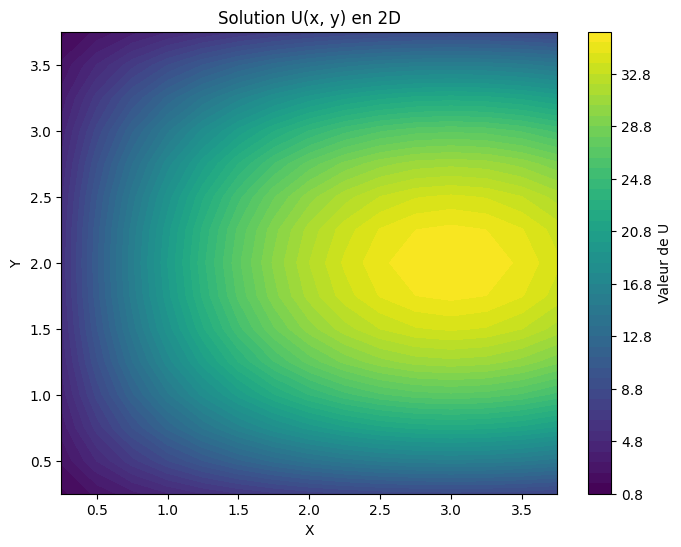

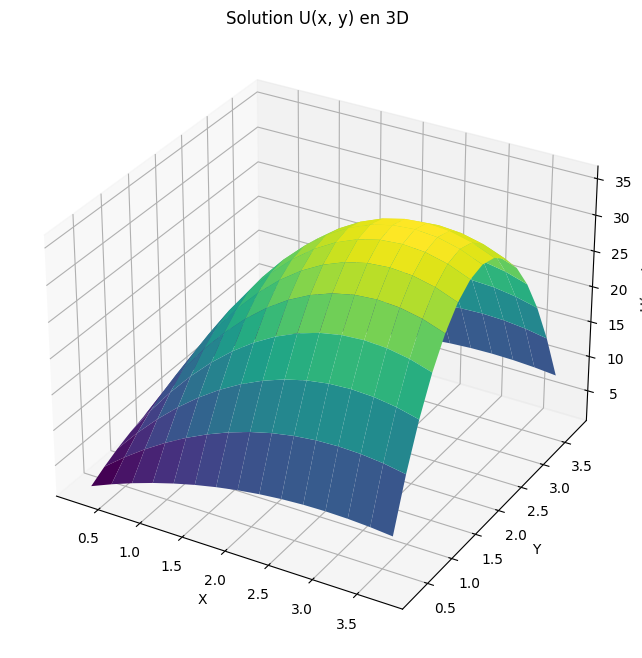

In [7]:
# Tracé en 2D avec une carte de couleurs
plt.figure(figsize=(8, 6))
plt.contourf(Xu, Yu, U_exacte.reshape(u(Xu,Yu).shape, order='C'), levels=50, cmap='viridis')  # Carte de couleurs
plt.colorbar(label='Valeur de U')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Solution U(x, y) en 2D')
plt.show()

# Tracé en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xu, Yu, U_exacte.reshape(u(Xu,Yu).shape, order='C'), cmap='viridis', edgecolor='none')  # Surface en 3D
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('Solution U(x, y) en 3D')
plt.show()

In [8]:
# méthode de sensibilité 
# je définie les vecteurs canoniques e_p et e_q de taille p*m et q*m

def ep(i,p,q,m) :  # pour i de 1 à m
    sol = np.zeros(p*m)
    sol[i*p-1] = 1
    return sol         # remarque, je peux faire d'autre truc, solve(Mu,ep/dx^2)

def eq(i,p,q,m) :              # pour i de 1 à m
    sol = np.zeros(q*m)
    sol[(i-1)*q] = 1
    return sol
# def matrice pour calculer le gradient 
def mat_Muep(m,Mu_inv,p,q):
    sol = np.zeros((m,p*m))
    for i in range(m):
        sol[i,:] = Mu_inv@ep(i+1,p,q,m)
    return -sol/dx**2
def mat_Mveq(m,Mv_inv,p,q):
    sol = np.zeros((m,q*m))
    for i in range(m):
        sol[i,:] = Mv_inv@eq(i+1,p,q,m)
    return sol/dx**2


In [9]:
g_initial = np.random.rand(m)
h_initial = np.random.rand(m)

In [10]:
# algorithme de sensibilité sans inverse
# première étape : la choix de g0 et h0
Mu_inv = np.linalg.inv(Mu)
Mv_inv = np.linalg.inv(Mv)

g0 = g_initial
h0 = h_initial

# 2-ème étape, calculons U^n et V^n 
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Muep=mat_Muep(m,Mu_inv,p,q)
Mveq=mat_Mveq(m,Mv_inv,p,q)

# 3-ème étape, calcule de gradients
Gu = dx*dy*Muep@R.T@(R@Un-S@Vn)
Gv = dx*dy*Mveq@S.T@(R@Un-S@Vn)

iter=0
eps = 10**(-2)
mu = 0.5
rh = 0.5
t1 = datetime.now()

while (np.linalg.norm(Gu) + np.linalg.norm(Gv) > eps ) :
    g0 = g0 - mu*Gu
    h0 = h0 - rh*Gv
    Un = solve(Mu,bu(g0,p,q,m,fu))
    Vn = solve(Mv,bv(h0,p,q,m,fv))
    Gu = dx*dy*Muep@R.T@(R@Un-S@Vn)
    Gv = dx*dy*Mveq@S.T@(R@Un-S@Vn)
    if iter == 5 :
        test_grad_sensabilite = Gu
    iter=iter+1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Un)**2) * dx*dy)
print(f"valeur d'intégrale = {np.matmul((np.matmul(R,Un)-np.matmul(S,Vn)).T,(np.matmul(R,Un)-np.matmul(S,Vn)))/2 *dx*dy}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)

KeyboardInterrupt: 

In [11]:
# algorithme de sensibilité avec inverse
# première étape : la choix de g0 et h0
Mu_inv = np.linalg.inv(Mu)
Mv_inv = np.linalg.inv(Mv)

g0 = g_initial
h0 = h_initial

# 2-ème étape, calculons U^n et V^n 
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Muep=mat_Muep(m,Mu_inv,p,q)
Mveq=mat_Mveq(m,Mv_inv,p,q)

# 3-ème étape, calcule de gradients
Gu = dx*dy*Muep@R.T@(R@Un-S@Vn)
Gv = dx*dy*Mveq@S.T@(R@Un-S@Vn)

iter=0
eps = 10**(-2)
mu = 0.5
rh = 0.5
t1 = datetime.now()

while (np.linalg.norm(Gu) + np.linalg.norm(Gv) > eps ) :
    g0 = g0 - mu*Gu
    h0 = h0 - rh*Gv
    Un = Mu_inv@bu(g0,p,q,m,fu)
    Vn = Mv_inv@bv(h0,p,q,m,fv)
    Gu = dx*dy*Muep@R.T@(R@Un-S@Vn)
    Gv = dx*dy*Mveq@S.T@(R@Un-S@Vn)
    if iter == 5 :
        test_grad_sensabilite = Gu
    iter=iter+1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Un)**2) * dx*dy)
print(f"valeur d'intégrale = {np.matmul((np.matmul(R,Un)-np.matmul(S,Vn)).T,(np.matmul(R,Un)-np.matmul(S,Vn)))/2 *dx*dy}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)

valeur d'intégrale = 0.005428211254422145
numbre d'iteration = 1957
En secondes : 0.25957
erreur relative =  0.004710305659617384


In [12]:

norm_u = np.sqrt(np.sum(U_exacte**2) * dV)

print(f"Erreur norme L2 : {norm_L2/norm_u}")

Erreur norme L2 : 5.923722717010286e-16


In [13]:
def mat_Mep(p,q,m):
    sol = np.zeros((m,m*p))
    for i in range(m):
        sol[i,:] = ep(i+1,p,q,m)
    return -sol/dx**2
def mat_Meq(p,q,m):
    sol = np.zeros((m,m*q))
    for i in range(m):
        sol[i,:] = eq(i+1,p,q,m)
    return sol/dx**2
def lamm_1(MuTRT,U,V):
    return dx*dy*MuTRT@(R@U-S@V)
def lamm_2(MvTST,U,V):
    return dx*dy*MvTST@(R@U-S@V)

In [14]:
# première étape : la choix de g0 et h0
g0 = np.copy(g_initial)
h0 = np.copy(h_initial)
MuT_fact = lu_factor(Mu.T)
MvT_fact = lu_factor(Mv.T)
# 2-ème étape, calculons U^n et V^n 
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))

# 3-ème étape, calcule de lambda_1 et lambda_2
MuTRT = Mu_inv.T@R.T
MvTST = Mv_inv.T@S.T
lambda_1 = lamm_1(MuTRT,Un,Vn)
lambda_2 = lamm_2(MvTST,Un,Vn)
# def Grad_bu(g) et Grad_bv(h)
Mep = mat_Mep(p,q,m)
Meq = mat_Meq(p,q,m)

gunn = Mep@lambda_1
gvnn = Meq@lambda_2
iter=0
eps = 10**(-2)
mu = 0.5
rh = 0.5
t1 = datetime.now()
while (np.linalg.norm(gunn) + np.linalg.norm(gvnn) > eps ) :
    g0 = g0 - mu*gunn
    h0 = h0 - rh*gvnn
    Un = solve(Mu,bu(g0,p,q,m,fu))
    Vn = solve(Mv,bv(h0,p,q,m,fv))
    lambda_1 = lamm_1(MuTRT,Un,Vn)
    lambda_2 = lamm_2(MvTST,Un,Vn)
    gunn = Mep@lambda_1
    gvnn = Meq@lambda_2
    if iter == 5 :
        test_grad_adjoint = gunn
    iter = iter +1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Un)**2) * dx*dy)
print(f"valeur d'intégral = {np.matmul((np.matmul(R,Un)-np.matmul(S,Vn)).T,(np.matmul(R,Un)-np.matmul(S,Vn)))/2 *dx*dy}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)

KeyboardInterrupt: 

In [ ]:
print(np.max(abs(test_grad_sensabilite- test_grad_adjoint)))

In [16]:
# première étape : la choix de g0 et h0
g0 = np.copy(g_initial)
h0 = np.copy(h_initial)
MuT_fact = lu_factor(Mu.T)
MvT_fact = lu_factor(Mv.T)
# 2-ème étape, calculons U^n et V^n 
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))

# 3-ème étape, calcule de lambda_1 et lambda_2
MuTRT = Mu_inv.T@R.T
MvTST = Mv_inv.T@S.T
lambda_1 = lamm_1(MuTRT,Un,Vn)
lambda_2 = lamm_2(MvTST,Un,Vn)
# def Grad_bu(g) et Grad_bv(h)
Mep = mat_Mep(p,q,m)
Meq = mat_Meq(p,q,m)

gunn = Mep@lambda_1
gvnn = Meq@lambda_2
iter=0
eps = 10**(-2)
mu = 0.5
rh = 0.5
t1 = datetime.now()
while (np.linalg.norm(gunn) + np.linalg.norm(gvnn) > eps ) :
    g0 = g0 - mu*gunn
    h0 = h0 - rh*gvnn
    Un = Mu_inv@bu(g0,p,q,m,fu)
    Vn = Mv_inv@bv(h0,p,q,m,fv)
    lambda_1 = lamm_1(MuTRT,Un,Vn)
    lambda_2 = lamm_2(MvTST,Un,Vn)
    gunn = Mep@lambda_1
    gvnn = Meq@lambda_2
    if iter == 5 :
        test_grad_adjoint = gunn
    iter = iter +1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Un)**2) * dx*dy)
print(f"valeur d'intégral = {np.matmul((np.matmul(R,Un)-np.matmul(S,Vn)).T,(np.matmul(R,Un)-np.matmul(S,Vn)))/2 *dx*dy}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)

valeur d'intégral = 0.005428211254422145
numbre d'iteration = 1957
En secondes : 0.758579
erreur relative =  0.004710305659617384


In [24]:
# on choisit au hasard g0 et h0, puis on calcule U et V 
# correspondante
g0 = np.random.rand(m)
h0 = np.random.rand(m)
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Xn = np.concatenate([Un, Vn, g0, h0])

# construction des matrices B et A
def mat_A_B(p,q,n,m,dx,dy,Mu,Mv,R,S):
    # 1) construction des matrices hat_G et hat_H
    hat_G = np.zeros((m*p,m))
    hat_H = np.zeros((m*q,m))
    for i in range(m):
        hat_G[(i+1)*p-1,i] = 1
        hat_H[i*q,i] = 1
    hat_G = hat_G/dx**2
    hat_H = hat_H/dx**2
    
    # définition da la matrice B
    B = np.zeros((m*(p+q),m*(p+q+2)))
    B[:m*p,:m*p]=Mu
    B[m*p:,m*p:m*(p+q)]=Mv
    B[:m*p,m*(p+q):m*(p+q+1)]=hat_G
    B[m*p:,m*(p+q+1):] = hat_H
    
    # définition de la matrice A
    A = np.zeros((m*(p+q+2),m*(p+q+2)))
    A[:m*p,:m*p] = np.matmul(R.T,R)
    A[m*p:m*(p+q),m*p:m*(p+q)] = np.matmul(S.T,S)
    A[:m*p,m*p:m*(p+q)] = -np.matmul(R.T,S)
    A[m*p:m*(p+q),:m*p] = -np.matmul(S.T,R)
    A =A*dx*dy/2
    return A,B
A, B = mat_A_B(p,q,n,m,dx,dy,Mu,Mv,R,S)
#A=A+np.eye(m*(p+q+2))/1000000

In [18]:
# gradient projeté avec inversion de matrice avet le boucle
g0 = np.random.rand(m)
h0 = np.random.rand(m)
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Xn = np.concatenate([Un, Vn, g0, h0])

# 2
BBT = np.matmul(B,B.T)
AXn = 2*np.matmul(A,Xn)
BAXn = np.matmul(B,AXn)
lamb_n = solve(BBT, BAXn)
BT= B.T
#3
gpn = AXn - np.matmul(B.T,lamb_n)
BBT_inv = np.linalg.inv(BBT)
epsi = 10**(-2)
iter = 0
mu = 0.5
t1 = datetime.now()
while np.linalg.norm(gpn)>epsi :
    Xn = Xn - mu* gpn
    AXn = 2*np.matmul(A,Xn)
    BAXn = np.matmul(B,AXn)
    lamb_n = BBT_inv @ BAXn
    gpn = AXn - np.matmul(B.T,lamb_n)
    iter = iter +1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Xn[:p*m])**2) * dx*dy)
print(f"valeur d'intégral = {np.matmul(Xn.T,AXn)}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)


valeur d'intégral = 0.06470331025907652
numbre d'iteration = 4665
En secondes : 0.617152
erreur relative =  0.011514774572338241


In [42]:
# BFGS et Armijo
# Initialisation
g0 = np.random.rand(m)
h0 = np.random.rand(m)
Un = solve(Mu, bu(g0,p,q,m,fu))
Vn = solve(Mv, bv(h0,p,q,m,fv))
Xn = np.concatenate([Un, Vn, g0, h0])

BBT = np.matmul(B, B.T)
BBT_fact = cho_factor(BBT)
AXn = 2 * np.matmul(A, Xn)
BAXn = np.matmul(B, AXn)
lamb_n = cho_solve(BBT_fact, BAXn)
gpn = AXn - np.matmul(B.T, lamb_n)
BBT_inv = np.linalg.inv(BBT)

# Critères d'arrêt
epsi = 1e-3
iter = 0
t1 = datetime.now()

# Initialisation pour BFGS
HH = np.eye(len(Xn))  # Matrice identité pour commencer

while np.linalg.norm(gpn) > epsi:
    # Calcul de la direction de descente
    d = -np.matmul(HH, gpn)
    
    # Recherche linéaire avec Armijo
    mu = 1.0
    beta = 0.5
    sigma = 0.1
    while True:
        X_new = Xn + mu * d
        AX_new = 2 * np.matmul(A, X_new)
        BAX_new = np.matmul(B, AX_new)
        lamb_new = BBT_inv@ BAX_new
        gpn_new = AX_new - np.matmul(B.T, lamb_new)
        
        # Condition d'Armijo
        if (np.matmul(X_new.T, AX_new) <= np.matmul(Xn.T, AXn) + sigma * mu * np.dot(gpn, d)):
            break
        mu *= beta

    # Mise à jour pour BFGS
    s = X_new - Xn
    y = gpn_new - gpn
    rho = 1.0 / np.dot(y, s)
    if rho > 0:  # Vérification de positivité
        I = np.eye(len(Xn))
        HH = (I - rho * np.outer(s, y)) @ HH @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)

    # Mise à jour des variables
    Xn = X_new
    AXn = AX_new
    gpn = gpn_new
    iter += 1

t2 = datetime.now()
delta = t2 - t1

# Résultats
print(f"Valeur d'intégral = {np.matmul(Xn.T, AXn)}")
print(f"Nombre d'itérations = {iter}")
print("En secondes :", delta.total_seconds())
print('m = ',m)
print(sol_grad_mat[:len(Xn)].T@A@sol_grad_mat[:len(Xn)] )

Valeur d'intégral = 0.3846683317079634
Nombre d'itérations = 40
En secondes : 0.319214
m =  15
0.1922385970325936


In [ ]:
# gradient projeté sans inversion de matrice avet le boucle
g0 = np.random.rand(m)
h0 = np.random.rand(m)
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Xn = np.concatenate([Un, Vn, g0, h0])

# 2
BBT = np.matmul(B,B.T)
AXn = 2*np.matmul(A,Xn)
BAXn = np.matmul(B,AXn)
lamb_n = solve(BBT, BAXn)
#3
gpn = AXn - np.matmul(B.T,lamb_n)
epsi = 10**(-2)
iter = 0
mu = 0.5
t1 = datetime.now()
while np.linalg.norm(gpn)>epsi :
    Xn = Xn - mu* gpn
    AXn = 2*np.matmul(A,Xn)
    BAXn = np.matmul(B,AXn)
    lamb_n = solve(BBT, BAXn)
    gpn = AXn - np.matmul(B.T,lamb_n)
    iter = iter +1
t2 = datetime.now()
delta = t2-t1
err = np.sqrt(np.sum((u(Xu,Yu).ravel(order='C')-Un)**2) * dx*dy)
print(f"valeur d'intégral = {np.matmul(Xn.T,AXn)}")
print(f"numbre d'iteration = {iter}")
print("En secondes :", delta.total_seconds())
print("erreur relative = ", err/norm_u)

In [33]:
g0 = np.random.rand(m)
h0 = np.random.rand(m)
Un = solve(Mu,bu(g0,p,q,m,fu))
Vn = solve(Mv,bv(h0,p,q,m,fv))
Xn = np.concatenate([Un, Vn, g0, h0])

# vérification qu'on a le bon C, Xn c'est la solution obtenue par la méthode Gradient projeté
C = np.concatenate([fu,fv])
gn = np.matmul(B,Xn)-C
print(np.linalg.norm(gn))

epsilon=10**(-15)
lamd_uzawa = np.linalg.inv(B@B.T)@B@A@Xn
X_test = np.linalg.inv(A.T@A + epsilon*np.eye(A.shape[1]))@A.T@B.T@lamd_uzawa
gn = np.matmul(B,X_test)-C
print(np.linalg.norm(gn))

2.6945594311696347e-12
4725673.005331886


In [40]:
zero_grad = np.zeros(A.shape[1])
X_mat_grad = np.concatenate([zero_grad,C])
# Construction de la matrice par blocs
zero_block = np.zeros((B.shape[0], B.shape[0]))  # Bloc de zéros de taille compatible
KKT_matrix = np.block([
    [A, -B.T], 
    [B, zero_block]
])

print(len(KKT_matrix))
t1 = datetime.now()
sol_grad_mat = solve(KKT_matrix,X_mat_grad)
t2 = datetime.now()
delta = t2-t1
print("En secondes :", delta.total_seconds())


810
En secondes : 0.076892


In [ ]:
# 1) choix de lambda
lamb = np.random.rand(m*(p+q))
mu = 0.05
# Paramètre de régularisation
epsilon = 10**(10)
print(np.linalg.matrix_rank(A))
# Construire la matrice pour la régularisation
ATA = 2 * (A.T @ A) + epsilon * np.eye(A.shape[1])
ATBT_lambda = A.T @ (B.T @ lamb)

# Résolution du système régularisé
ATA_fact = cho_factor(ATA)
Xn = cho_solve(ATA_fact, ATBT_lambda)


# 3 calcule de g^n
gn = np.matmul(B,Xn)-C
print(np.linalg.norm(gn))
while np.linalg.norm(gn)>epsi :
    lamb = lamb - mu * gn  
    ATBT_lambda = A.T @ (B.T @ lamb)
    Xn = cho_solve(ATA_fact, ATBT_lambda)
    gn = np.matmul(B,Xn)-C
    print(np.linalg.norm(gn))
